# 05. Applying Supervised Learning Algorithms (Logistic Regression)

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply logistic regression to labeled data
- Understand supervised learning
- Train classification models
- Evaluate model performance
- Apply to binary and multi-class problems

## 🔗 Where this fits

**Builds on:** Course 04 (AIAT 114) — Unit 3, lesson 01 "Logistic Regression and Classification Metrics" — the same model and metrics inside this unit's workflow; the fit is still the cross-entropy loss of Course 01 (AIAT 111) — Unit 3, lesson 04, minimised for you.

**Used later in:** Course 05 — Unit 4, lesson 06, which compares it with other classifiers on one dataset.

---

This notebook covers practical activities from **Course 05, Unit 4**:
- Applying supervised learning algorithms on labeled data (e.g., logistic regression)

---

## Introduction

**Supervised learning** uses labeled data to train models that can predict outcomes, with logistic regression being a fundamental algorithm for classification tasks.


## 🎯 The case: the coefficients your doctor still uses

The **Framingham Risk Score** estimates a person's 10-year risk of cardiovascular disease
from age, cholesterol, HDL, blood pressure and smoking status. It is a logistic-style
risk model published in 1998, updated in 2002 and 2008, and it is used in clinical practice
around the world — because a physician can read it, argue with it, and explain to a patient
which factor moved their number.

It also carries a documented limit that no amount of accuracy fixes: the score was fitted
on a specific population, and it can **over- or under-estimate risk in populations other
than the one it was built on** — a known issue for several groups within the United States
alone. A model whose coefficients you can read is also a model whose coefficients you can
check against a new population. That is the trade this lesson is about.

**What goes wrong without probabilities.** Lesson 04 pushed linear regression at a
classification task and produced a "probability" of **1.59**. Logistic regression cannot
do that: the sigmoid bounds the output in [0, 1], so the number you get out is something
you can threshold, calibrate, or hand to a decision-maker as a risk.

**And the case that shows why probabilities are not enough.** ProPublica's 2016 analysis of
the **COMPAS** recidivism tool examined 7,214 defendants and found that among those who did
*not* reoffend, **44.9% of Black defendants** had been labelled high-risk against **23.5%
of white defendants**; among those who *did* reoffend, **47.7% of white defendants** were
labelled low-risk against **28.0% of Black defendants**. Northpointe's reply was that the
scores were equally *calibrated* across groups — and both claims were arithmetically true.
Where you put the threshold, and which error you are willing to make, is not a
mathematical question.


## The Story

**BEFORE**: You know linear regression but don't understand classification models.

**AFTER**: You'll learn logistic regression - the foundation of classification, understanding probabilities and decision boundaries!

**Why this matters**: Applying Supervised Learning Algorithms (Logistic Regression) is essential for building complete, professional data science solutions!

---

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Features X, binary target y
- sklearn

**Outputs:** What you'll see when you run the cells

- Logistic model
- Metrics
- Plots

---

In [1]:
# WHAT: Import sklearn's logistic regression tools, load the real Titanic manifest, and recap supervised learning.
# WHY: Logistic regression is the standard first classifier - a baseline every fancier model must beat.

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("✅ Libraries imported!")
print("\nSupervised Learning: Logistic Regression")
print("=" * 60)
print("""
Supervised learning recap (from Course 04 - AIAT 114):
  - We learn from LABELED data: features X plus known answers y
  - The model finds the mapping X -> y, then predicts y for new X
  - Logistic regression is the classic CLASSIFICATION baseline:
    it outputs P(class) via the sigmoid function, then thresholds it

The labels in this notebook are historical fact: who survived the Titanic,
and which of three cultivars each wine sample came from.
""")

✅ Libraries imported!

Supervised Learning: Logistic Regression

Supervised learning recap (from Course 04 - AIAT 114):
  - We learn from LABELED data: features X plus known answers y
  - The model finds the mapping X -> y, then predicts y for new X
  - Logistic regression is the classic CLASSIFICATION baseline:
    it outputs P(class) via the sigmoid function, then thresholds it

The labels in this notebook are historical fact: who survived the Titanic,
and which of three cultivars each wine sample came from.



## Part 1: Binary Classification — Train and Evaluate

We create a small labeled dataset (two features, two classes), split it into
train/test, fit a logistic regression model, and evaluate it — the complete
supervised workflow in one pass.

In [2]:
# WHAT: Train logistic regression on the real Titanic manifest, then read accuracy, the confusion matrix and probabilities.
# WHY: The confusion matrix shows WHERE the model errs (false positives vs false negatives), which accuracy alone hides.

print("Part 1: Binary classification - who survived the Titanic?")
print("-" * 60)

DATA_DIR = '../../../Course 04/datasets/raw/'
titanic = pd.read_csv(DATA_DIR + 'titanic.csv')

# Minimal honest preparation: fill the 177 real missing ages with the median,
# turn Sex into a 0/1 flag. Everything else is used as recorded.
tit = titanic[['Age', 'Fare', 'SibSp', 'Parch', 'Pclass', 'Sex', 'Survived']].copy()
n_missing_age = tit['Age'].isna().sum()
tit['Age'] = tit['Age'].fillna(tit['Age'].median())
tit['is_female'] = (tit['Sex'] == 'female').astype(int)

FEATURES = ['Age', 'Fare', 'SibSp', 'Parch', 'Pclass', 'is_female']
X = tit[FEATURES].values
y = tit['Survived'].values
print(f"{len(tit)} passengers, {len(FEATURES)} features "
      f"({n_missing_age} missing ages median-filled)")
print(f"Class balance: {int((y == 0).sum())} died / {int((y == 1).sum())} survived "
      f"({y.mean():.1%} positive)")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
print(f"Training samples: {len(X_train)}, test samples: {len(X_test)}")

# Scale: fare runs 0-512 while SibSp runs 0-8, and logistic regression's
# optimiser converges far better on comparable scales.
scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)

acc = accuracy_score(y_test, y_pred)
baseline = max(y_test.mean(), 1 - y_test.mean())
print(f"\nTest accuracy: {acc:.2%}   (majority-class baseline: {baseline:.2%})")
print("\nConfusion matrix (rows=actual, cols=predicted):")
print(confusion_matrix(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3,
                            target_names=['died', 'survived']))

print("Learned coefficients (on standardised features - bigger = more influence):")
for name, coef in sorted(zip(FEATURES, model.coef_[0]), key=lambda t: -abs(t[1])):
    print(f"  {name:10s} {coef:+.3f}  ({'raises' if coef > 0 else 'lowers'} survival odds)")

# The part linear regression could not give us: real probabilities
proba = model.predict_proba(X_test_s[:5])
print("\nPredicted probabilities for the first 5 test passengers:")
for i, (p0, p1) in enumerate(proba):
    print(f"  passenger {i}: P(died)={p0:.3f}  P(survived)={p1:.3f}  "
          f"-> predicted {y_pred[i]}, actual {y_test[i]}")
print("\n💡 Every row sums to 1 and stays inside [0, 1] - which is exactly what")
print("   thresholded linear regression could not promise in Example 04.")

Part 1: Binary classification - who survived the Titanic?
------------------------------------------------------------
891 passengers, 6 features (177 missing ages median-filled)
Class balance: 549 died / 342 survived (38.4% positive)
Training samples: 668, test samples: 223

Test accuracy: 78.03%   (majority-class baseline: 61.43%)

Confusion matrix (rows=actual, cols=predicted):
[[112  25]
 [ 24  62]]

Classification report:
              precision    recall  f1-score   support

        died      0.824     0.818     0.821       137
    survived      0.713     0.721     0.717        86

    accuracy                          0.780       223
   macro avg      0.768     0.769     0.769       223
weighted avg      0.781     0.780     0.781       223

Learned coefficients (on standardised features - bigger = more influence):
  is_female  +1.289  (raises survival odds)
  Pclass     -0.899  (lowers survival odds)
  Age        -0.523  (lowers survival odds)
  SibSp      -0.276  (lowers surviv

## Part 2: The Decision Boundary

Logistic regression learns a boundary where P(class 1) = 0.5. Let's draw it.

Part 2: Visualizing the decision boundary
------------------------------------------------------------
Two-feature model (Age, Fare) test accuracy: 61.43% vs 78.03% with all 6 features


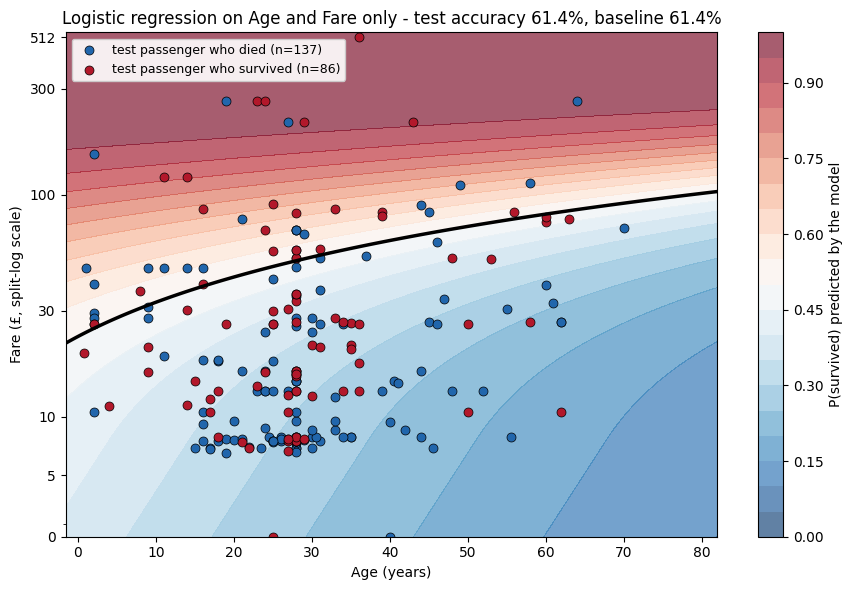

✓ Decision boundary plotted (black line = P(survived) = 0.5)
  The fare axis is linear up to £8 and logarithmic above it, because three real
  tickets cost £512 while the median was £14 - on a plain linear axis every other
  passenger would be squashed into the bottom centimetre of the plot.
  The 0.5 boundary, read off the fitted model:
    at age 10: a passenger must have paid about £33 before the model predicts 'survived'
    at age 40: a passenger must have paid about £62 before the model predicts 'survived'
    at age 70: a passenger must have paid about £91 before the model predicts 'survived'

⚠️  Honest reading of this figure: the boundary looks convincing, but this
   model predicts 'survived' for only 21% of the test set and its
   61.43% accuracy merely MATCHES the majority baseline (61.43%).
   Age and fare alone do not separate the classes - sex does, and it is not on
   this plot. A drawable boundary is not the same as a useful model.


In [3]:
# WHAT: Color the Age-Fare plane by predicted probability and draw the 0.5 contour.
# WHY: Seeing the decision boundary makes 'the model learned a rule' concrete - it is a line in feature space.

print("Part 2: Visualizing the decision boundary")
print("-" * 60)

# A two-feature model so the boundary can be drawn on paper: age and fare.
# Fewer features means lower accuracy - we report both so the trade-off is visible.
X2 = tit[['Age', 'Fare']].values
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.25, random_state=42, stratify=y)
scaler2 = StandardScaler().fit(X2_train)
model2 = LogisticRegression(max_iter=1000).fit(scaler2.transform(X2_train), y2_train)
acc2 = accuracy_score(y2_test, model2.predict(scaler2.transform(X2_test)))
print(f"Two-feature model (Age, Fare) test accuracy: {acc2:.2%} "
      f"vs {acc:.2%} with all {len(FEATURES)} features")

# Build the probability grid over the range the DATA actually occupies. A fare cannot be
# negative, so the grid starts at £0 - anything below that would be drawn-in nonsense.
FARE_FLOOR, FARE_CEIL = 0.0, X2[:, 1].max() * 1.05
xx, yy = np.meshgrid(np.linspace(X2[:, 0].min() - 2, X2[:, 0].max() + 2, 200),
                     np.linspace(FARE_FLOOR, FARE_CEIL, 300))
grid = scaler2.transform(np.c_[xx.ravel(), yy.ravel()])
Z = model2.predict_proba(grid)[:, 1].reshape(xx.shape)

fig, ax = plt.subplots(figsize=(9, 6))
cf = ax.contourf(xx, yy, Z, levels=np.linspace(0, 1, 21), cmap='RdBu_r', alpha=0.65)
fig.colorbar(cf, ax=ax, label='P(survived) predicted by the model')
ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2.5)

# Plot the two outcome groups separately so they can carry a real legend.
for label, colour, name in [(0, '#2166ac', 'died'), (1, '#b2182b', 'survived')]:
    m = y2_test == label
    ax.scatter(X2_test[m, 0], X2_test[m, 1], c=colour, edgecolors='black',
               linewidths=0.5, s=42, label=f'test passenger who {name} (n={int(m.sum())})')

# symlog with an explicit linear threshold: linear from £0 to £10 (where the free and
# cheap tickets are), logarithmic above it - and NO negative region.
ax.set_yscale('symlog', linthresh=8, linscale=0.4)
ax.set_ylim(FARE_FLOOR, FARE_CEIL)
ax.set_yticks([0, 5, 10, 30, 100, 300, 512])
ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_title(f'Logistic regression on Age and Fare only - test accuracy {acc2:.1%}, '
             f'baseline {baseline:.1%}')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Fare (£, split-log scale)')
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()
print("✓ Decision boundary plotted (black line = P(survived) = 0.5)")
print("  The fare axis is linear up to £8 and logarithmic above it, because three real")
print("  tickets cost £512 while the median was £14 - on a plain linear axis every other")
print("  passenger would be squashed into the bottom centimetre of the plot.")
# Where exactly does the 0.5 boundary sit? Read it off the fitted model at three ages.
fare_axis = np.linspace(0, X2[:, 1].max(), 4000)
print("  The 0.5 boundary, read off the fitted model:")
for age in (10, 40, 70):
    p = model2.predict_proba(scaler2.transform(
        np.c_[np.full_like(fare_axis, age), fare_axis]))[:, 1]
    crossings = np.where(p >= 0.5)[0]
    fare_at_half = fare_axis[crossings[0]] if len(crossings) else float('nan')
    print(f"    at age {age:2d}: a passenger must have paid about £{fare_at_half:.0f} "
          f"before the model predicts 'survived'")
pred2 = model2.predict(scaler2.transform(X2_test))
print(f"\n⚠️  Honest reading of this figure: the boundary looks convincing, but this")
print(f"   model predicts 'survived' for only {pred2.mean():.0%} of the test set and its")
print(f"   {acc2:.2%} accuracy merely MATCHES the majority baseline ({baseline:.2%}).")
print("   Age and fare alone do not separate the classes - sex does, and it is not on")
print("   this plot. A drawable boundary is not the same as a useful model.")

**Read the figure.** Age runs along the bottom, fare up the side (linear to £8, logarithmic
above, so the three real £512 tickets do not flatten everyone else), and the background colour
is the probability this two-feature model assigns to "survived" — blue low, red high. The thick
black curve is where that probability crosses 0.5: the model's actual decision rule. It climbs
from about **£33 at age 10 to £91 at age 70**, so a passenger has to have paid several times the
median fare before the model will call them a survivor at all — which is why it predicts
"survived" for only **21%** of the test set, and four fifths of the dots sit in the blue field.

Now look at the dots themselves. Red (survived) and blue (died) are **mixed together throughout
that blue field**, at every age and every fare; there is no band where one colour takes over.
That mixing is the honest result — **this is a good drawing of a bad model**. Its 61.4% accuracy
is exactly the majority-class baseline printed in the title. Sex is the variable that separates
these two colours, and it is not on this plot. A drawable boundary is not the same as a useful
model.

## 💬 Discuss

The full model scores **78.03%** against a **61.43%** baseline, with a confusion matrix of
`[[112, 25], [24, 62]]` on 223 test passengers — precision 0.713 and recall 0.721 for
"survived". The two-feature Age/Fare model scores **61.43%**: exactly the baseline.

1. The two-feature model draws a beautiful decision boundary and predicts "survived" for
   only 21% of the test set, matching the majority baseline exactly. What is it actually
   doing, and what does this teach you about judging a model by its picture?
2. The confusion matrix shows **25 false positives and 24 false negatives** — almost
   perfectly balanced. Now change the application: this same model scores who gets a
   lifeboat seat. Which error do you want fewer of, and what do you change to get it? Then
   argue the opposite side.
3. COMPAS was **calibrated** across race and had **unequal error rates** across race. Both
   were true simultaneously. Using the confusion matrix above, explain in your own words why
   those two properties cannot generally both hold — and say which one you would demand if
   the model were used on loan applications in your own country.


## Part 3: Multi-class Classification

The same estimator handles more than two classes — scikit-learn extends
logistic regression to multi-class automatically.

In [4]:
# WHAT: Fit the same model on a real three-class problem and print per-class probabilities.
# WHY: Logistic regression extends to multi-class seamlessly - each row of predict_proba sums to 1.

print("Part 3: Multi-class classification")
print("-" * 60)

from sklearn.datasets import load_wine

# Real data: 178 Italian wine samples from three different cultivars, each
# described by 13 chemical measurements (Forina et al., UCI repository).
wine = load_wine()
X_mc, y_mc = wine.data, wine.target
print(f"{X_mc.shape[0]} wine samples x {X_mc.shape[1]} chemical measurements")
print(f"Class sizes: {dict(zip(wine.target_names, np.bincount(y_mc)))}")

Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X_mc, y_mc, test_size=0.25, random_state=7, stratify=y_mc)

# Chemical measurements span very different ranges (proline is in the hundreds,
# hue is near 1), so scaling is not optional here.
mc_scaler = StandardScaler().fit(Xm_train)
mc_model = LogisticRegression(max_iter=5000)
mc_model.fit(mc_scaler.transform(Xm_train), ym_train)
mc_acc = accuracy_score(ym_test, mc_model.predict(mc_scaler.transform(Xm_test)))

print(f"\nClasses: {list(wine.target_names)}")
print(f"Multi-class test accuracy: {mc_acc:.2%}")
proba3 = mc_model.predict_proba(mc_scaler.transform(Xm_test[:3]))
print("\nPer-class probabilities for 3 test samples (rows sum to 1):")
print("   " + "  ".join(f"{n:>10s}" for n in wine.target_names))
for row in proba3:
    print("   " + "  ".join(f"{p:10.3f}" for p in row))
print("\n💡 The three cultivars are chemically distinct, so this problem is much")
print("   easier than Titanic survival - the probabilities are near 0 or 1.")

Part 3: Multi-class classification
------------------------------------------------------------
178 wine samples x 13 chemical measurements
Class sizes: {np.str_('class_0'): np.int64(59), np.str_('class_1'): np.int64(71), np.str_('class_2'): np.int64(48)}

Classes: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]
Multi-class test accuracy: 97.78%

Per-class probabilities for 3 test samples (rows sum to 1):
      class_0     class_1     class_2
        0.003       0.001       0.996
        0.001       0.998       0.000
        0.001       0.990       0.009

💡 The three cultivars are chemically distinct, so this problem is much
   easier than Titanic survival - the probabilities are near 0 or 1.


In [5]:
# WHAT: Print the summary with the accuracies computed above.
# WHY: The numbers come from live variables, so the recap always matches what this run actually produced.

print("=" * 60)
print("Summary")
print("=" * 60)
print(f"""
What we actually did in this notebook, on two real datasets:
  1. Trained a logistic regression classifier on the {len(tit)}-passenger Titanic manifest
     -> binary test accuracy: {acc:.2%} (majority-class baseline {baseline:.2%})
  2. Evaluated it: accuracy, confusion matrix, classification report
  3. Read real probabilities from predict_proba (unlike linear regression)
  4. Visualized the learned decision boundary on Age x Fare
     -> that two-feature model scored {acc2:.2%}: fewer features, less accuracy
  5. Extended the same model to the 3 wine cultivars -> accuracy: {mc_acc:.2%}

Honest note: {acc:.0%} on Titanic is close to what published analyses of this dataset
report for a linear model. Survival was not fully determined by the six recorded
columns, and no amount of tuning will make it so.

Next: Example 06 compares logistic regression against decision trees
with confusion matrices and ROC curves.
""")
print("✅ Supervised learning with logistic regression - complete!")

Summary

What we actually did in this notebook, on two real datasets:
  1. Trained a logistic regression classifier on the 891-passenger Titanic manifest
     -> binary test accuracy: 78.03% (majority-class baseline 61.43%)
  2. Evaluated it: accuracy, confusion matrix, classification report
  3. Read real probabilities from predict_proba (unlike linear regression)
  4. Visualized the learned decision boundary on Age x Fare
     -> that two-feature model scored 61.43%: fewer features, less accuracy
  5. Extended the same model to the 3 wine cultivars -> accuracy: 97.78%

Honest note: 78% on Titanic is close to what published analyses of this dataset
report for a linear model. Survival was not fully determined by the six recorded
columns, and no amount of tuning will make it so.

Next: Example 06 compares logistic regression against decision trees
with confusion matrices and ROC curves.

✅ Supervised learning with logistic regression - complete!


## ⚠️ Where this breaks

- **"Logistic regression" is still a linear model.** It fits a linear boundary in the
  feature space; the sigmoid only bends the *output*. If the true boundary is curved, no
  amount of data fixes it — you add interaction terms, polynomial features, or a different
  model.
- **Coefficients are odds ratios only after exponentiating, and only conditional on the
  other features.** `is_female +1.289` on standardised features means "one standard
  deviation of this column moves the log-odds by 1.289, holding the other five fixed" — a
  sentence with two conditions most reports drop.
- **The 0.5 threshold is a default, not a decision.** It is optimal only when false
  positives and false negatives cost the same and the classes are balanced. Neither is true
  here, and neither is true in fraud detection (0.173% positives, Unit 2 lesson 07) or in
  criminal risk assessment.
- **Predicted probabilities are not automatically calibrated.** A model can rank cases
  perfectly and still say "0.9" for cases that happen 60% of the time — especially after
  resampling or class weighting. Check a reliability curve before anyone treats the output
  as a risk.
- **Fairness definitions conflict, provably.** Equal calibration across groups and equal
  error rates across groups cannot generally hold together when base rates differ. COMPAS
  is the canonical demonstration. You must choose, and the choice is ethical and legal,
  not statistical.
- **The assumption that must hold: the population you predict on resembles the one you
  fitted on.** Framingham's documented over- and under-estimation in other populations is
  what that failure looks like in a model that has been checked. Most models are not
  checked.
- **Cheaper alternative:** when only accuracy matters and nobody has to read the model, a
  gradient-boosted tree will usually beat logistic regression on tabular data. Choose
  logistic regression when you need to *state* the model — for a regulator, a clinician, or
  a credit decision that must be explained to the applicant.


## 📚 References

1. Cox, D. R. (1958). *The Regression Analysis of Binary Sequences*. Journal of the Royal Statistical Society, Series B, 20(2), 215-242.
2. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning*, 2nd ed., Ch. 4 (Classification). Springer. <https://www.statlearning.com>
3. Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*, Ch. 4 (Linear Models for Classification). Springer.
4. Erickson, N., Purucker, L., Tschalzev, A., et al. (2025). *TabArena: A Living Benchmark for Machine Learning on Tabular Data*. arXiv:2506.16791. <https://arxiv.org/abs/2506.16791>
5. Pfefferle et al. (2025). *nanoTabPFN: A Lightweight and Educational Reimplementation of TabPFN*. arXiv:2511.03634. <https://arxiv.org/abs/2511.03634>
